In [ ]:
#load the data
# We load the data and split it into train, validation and test sets. The test set is kept separate for final evaluation after model selection and tuning is done on the train and validation sets.

import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("../data/raw/train_transactions.csv")
test_df = pd.read_csv("../data/raw/test_transactions.csv")

X_train_full = train_df['transaction_text']
y_train_full = train_df['category']

X_test = test_df['transaction_text']
y_test = test_df['category']

#split train into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)


print(f"Train: {len(X_train)}, Val: {len(X_val)}, test: {len(X_test)}")


Train: 4000, Val: 1000, test: 1000


In [ ]:
#clean the text by removing amounts, transaction ids, and other numbers. This will help the model focus on the actual text rather than specific numbers which may not generalize well.

import re

def clean_text(text):
    text = re.sub(r'INR\s*\d+', '', text)
    text = re.sub(r'TXN+\w+', '', text)
    text = re.sub(r'\d+', '', text)
    return text.strip().lower()

X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

#what's left after cleaning?
print(X_train_clean.head(10).to_list())

['gas bill payment', 'mutual fund sip', 'college fees payment', 'electricity bill payment', 'game purchase', 'bike loan emi', 'ppf contribution', 'food court payment', 'swiggy order', 'netflix subscription']


In [ ]:
#tfidf vectorization and logistic regression model training
#convert the cleaned text into numerical features using TF-IDF vectorization and then train a logistic regression model on the training data. We will evaluate the model on the validation set to see how well it performs.

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

tfidf= TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_val_tfidf)

print("Logistic Regression:")
print(classification_report(y_val, y_pred))

Logistic Regression:
               precision    recall  f1-score   support

    education       1.00      1.00      1.00       121
          emi       1.00      1.00      1.00       108
entertainment       1.00      1.00      1.00       111
         food       1.00      1.00      1.00       107
   healthcare       1.00      1.00      1.00       114
   investment       1.00      1.00      1.00       106
     shopping       1.00      1.00      1.00       109
       travel       1.00      1.00      1.00       113
    utilities       1.00      1.00      1.00       111

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



In [ ]:
#random forest for comparison
# trains a random forest classifier to see if it performs better than logistic regression on this task. Random forests can capture more complex relationships in the data, but they may also be more prone to overfitting, especially with high-dimensional data like text features.
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)
y_pred_rf = model_rf.predict(X_val_tfidf)
print("Random Forest:")
print(classification_report(y_val, y_pred_rf))

Random Forest:
               precision    recall  f1-score   support

    education       1.00      1.00      1.00       121
          emi       1.00      1.00      1.00       108
entertainment       1.00      1.00      1.00       111
         food       1.00      1.00      1.00       107
   healthcare       1.00      1.00      1.00       114
   investment       1.00      1.00      1.00       106
     shopping       1.00      1.00      1.00       109
       travel       1.00      1.00      1.00       113
    utilities       1.00      1.00      1.00       111

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



In [ ]:
#select the best model based on validation performance
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_val, y_pred)
acc_rf = accuracy_score(y_val, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

if acc_rf >= acc_lr:
    print("Random Forest performs better, or as good as Logistic Regression. Selecting Random Forest for final evaluation.")
    best_model = model_rf
    best_name = "Random Forest"
else:
    print("Logistic Regression performs better. Selecting Logistic Regression for final evaluation.")
    best_model = model
    best_name = "Logistic Regression"



Logistic Regression Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Random Forest performs better, or as good as Logistic Regression. Selecting Random Forest for final evaluation.


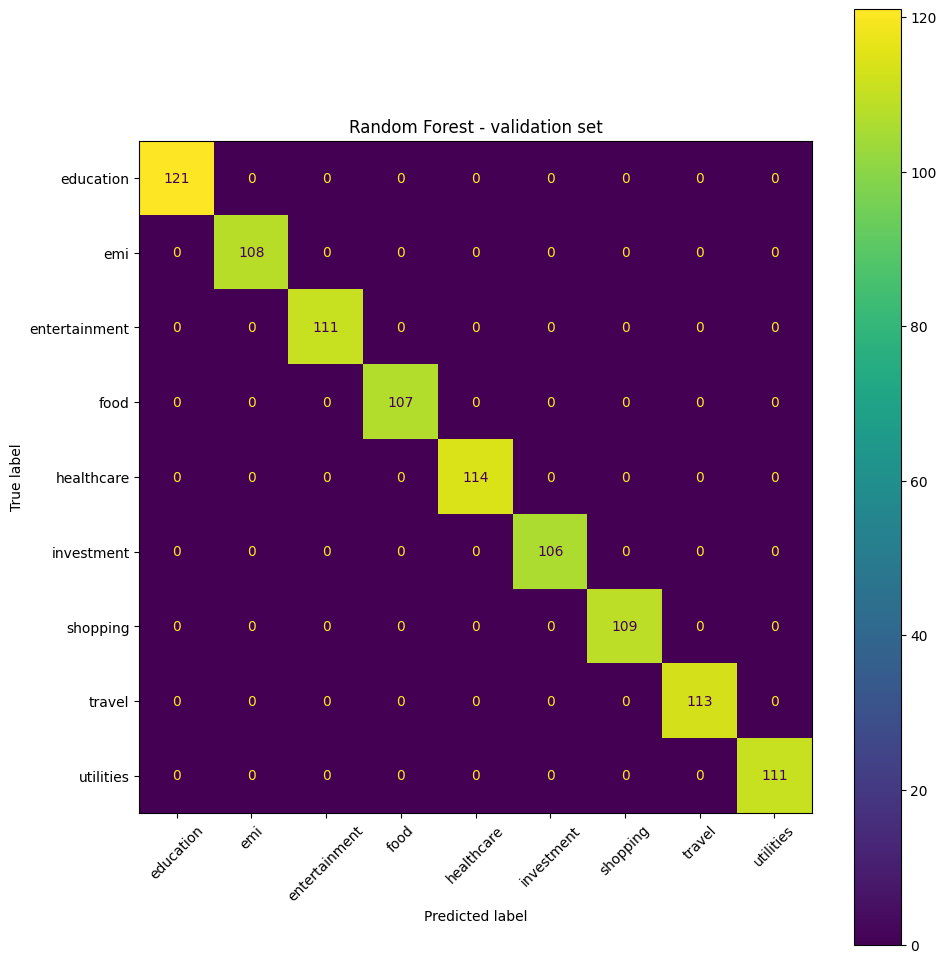

In [ ]:
#confusion matrix for best model 
# The confusion matrix provides a visual representation of the model's performance, showing how many instances were correctly classified and where the model made mistakes. This can help identify specific categories that the model struggles with and guide further improvements.
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, xticks_rotation=45)
plt.title(f"{best_name} - validation set")
plt.tight_layout()
plt.show()


In [ ]:
# Final evaluation on test set
X_test_tfidf = tfidf.transform(X_test_clean)
y_test_pred = best_model.predict(X_test_tfidf)
print(f"Final evaluation on test set ({best_name}):")
print(classification_report(y_test, y_test_pred))



Final evaluation on test set (Random Forest):
               precision    recall  f1-score   support

    education       1.00      1.00      1.00       121
          emi       1.00      1.00      1.00       121
entertainment       1.00      1.00      1.00        96
         food       1.00      1.00      1.00       111
   healthcare       1.00      1.00      1.00       111
   investment       1.00      1.00      1.00       115
     shopping       1.00      1.00      1.00       102
       travel       1.00      1.00      1.00       114
    utilities       1.00      1.00      1.00       109

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



In [ ]:
#save model and vectorizer for deployment
import joblib
import os

os.makedirs("../src", exist_ok=True)
joblib.dump(best_model, "../src/model.joblib")
joblib.dump(tfidf, "../src/tfidf.joblib")

print("Model and vectorizer saved to /src for deployment.")


Model and vectorizer saved to /src for deployment.
